### Loading packages

In [93]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

### Understand data

In [94]:
train_data = pd.read_csv("data/train_ctrUa4K.csv")
test_data = pd.read_csv("data/test_lAUu6dG.csv")
# make copies of sets in order to not lose original datasets if we make any changes
train_original = train_data.copy()
test_original = test_data.copy()

In [95]:
# data columns
print('shape of train data is : ', train_data.shape)
print('shape of test data is : ', test_data.shape)
train_data.head()

shape of train data is :  (614, 13)
shape of test data is :  (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Loan_Status is the traget variable

In [96]:
# data types
train_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

WE have 3 types of data: categorical, integer and numerical(float) 

### EDA

#### Univariate Analysis

analyse each variable individually
- for categorical variables: bar plot ,percentage distribution and frequency table to calcultate the number of observations for each category
- for numerical variables: probability density plots to look at the distribution of features

##### 1. target variable

## count Loan_Status
Y    422
N    192
Name: count, dtype: int64
## Percentage distribution Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


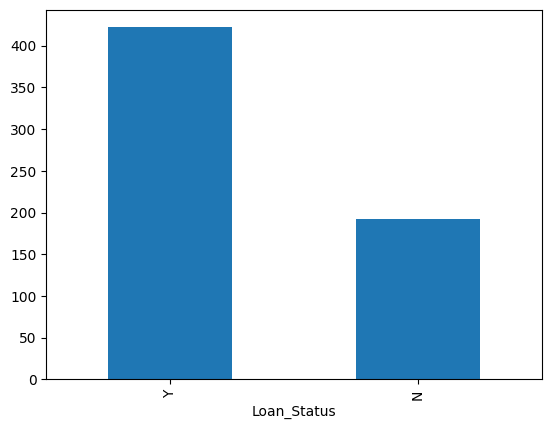

In [97]:
# frequency table: count of each category
print('## count', train_data.Loan_Status.value_counts())
# percentage distribution
print('## Percentage distribution', train_data.Loan_Status.value_counts(normalize=True))
print(train_data.Loan_Status.value_counts().plot.bar())

About 69% of people their loans are approved and 31% are rejected

##### 2. Independant variables

WE have variables of type categirical, ordinal and numerical

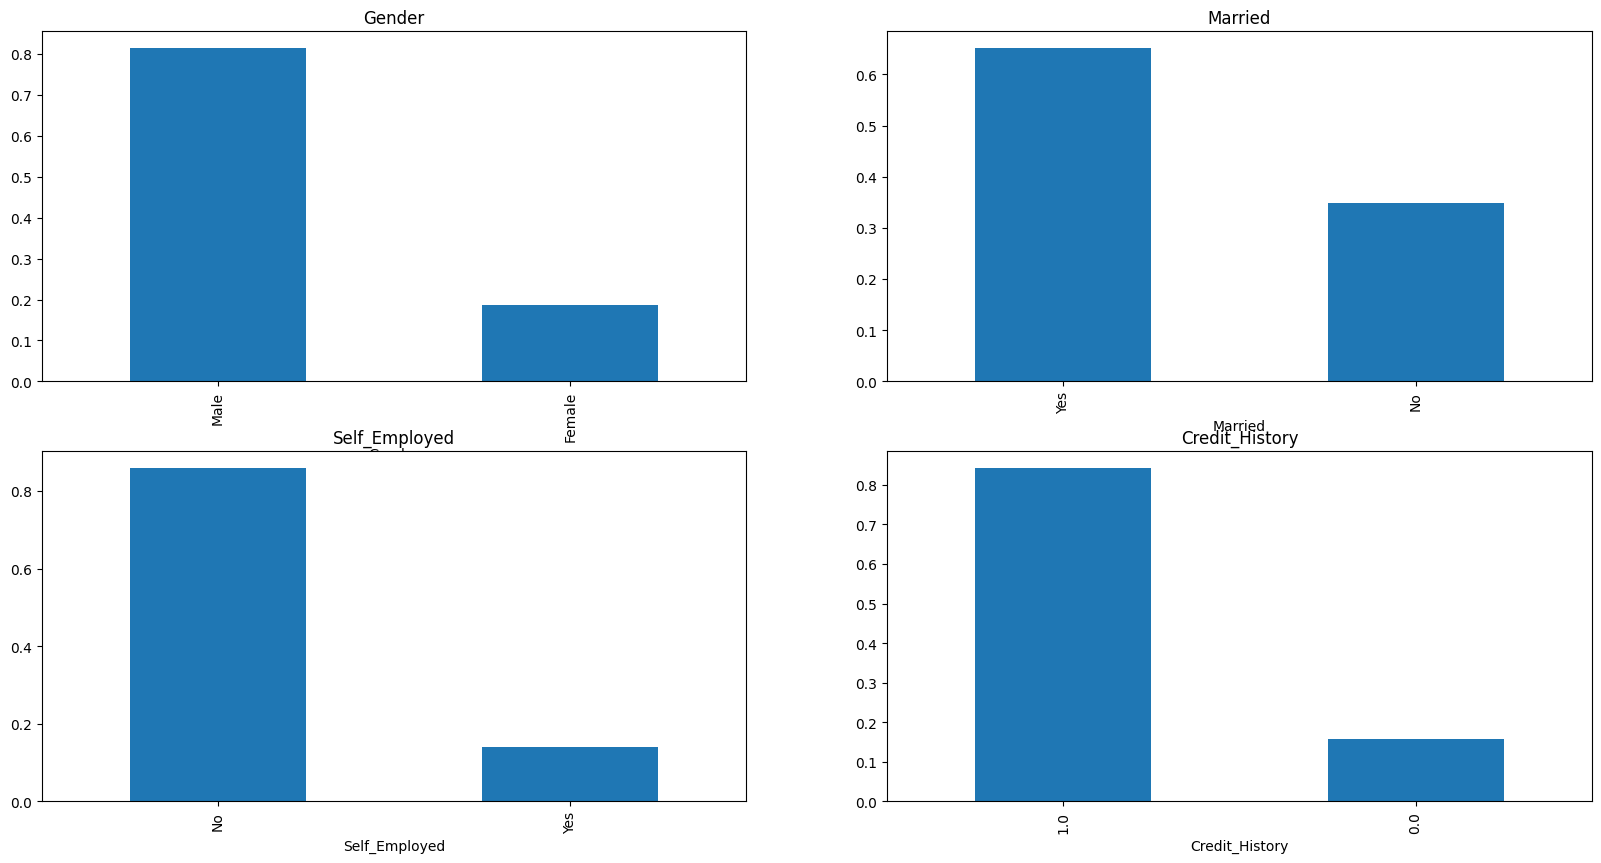

In [98]:
plt.figure(1)
plt.subplot(221)
train_data.Gender.value_counts(normalize=True).plot.bar(figsize=(20,10), title='Gender')
plt.subplot(222)
train_data.Married.value_counts(normalize=True).plot.bar(figsize=(20,10), title='Married')
plt.subplot(223)
train_data.Self_Employed.value_counts(normalize=True).plot.bar( title='Self_Employed')
plt.subplot(224)
train_data.Credit_History.value_counts(normalize=True).plot.bar(figsize=(20,10), title='Credit_History')
# plt.subplot(225)
plt.show()

It can be inferred from the above bar plots that:
- 80% applicants in the dataset are male
- Arount 65% of applicants are married
- Around 15% of applicants are self employed

In [99]:
train_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

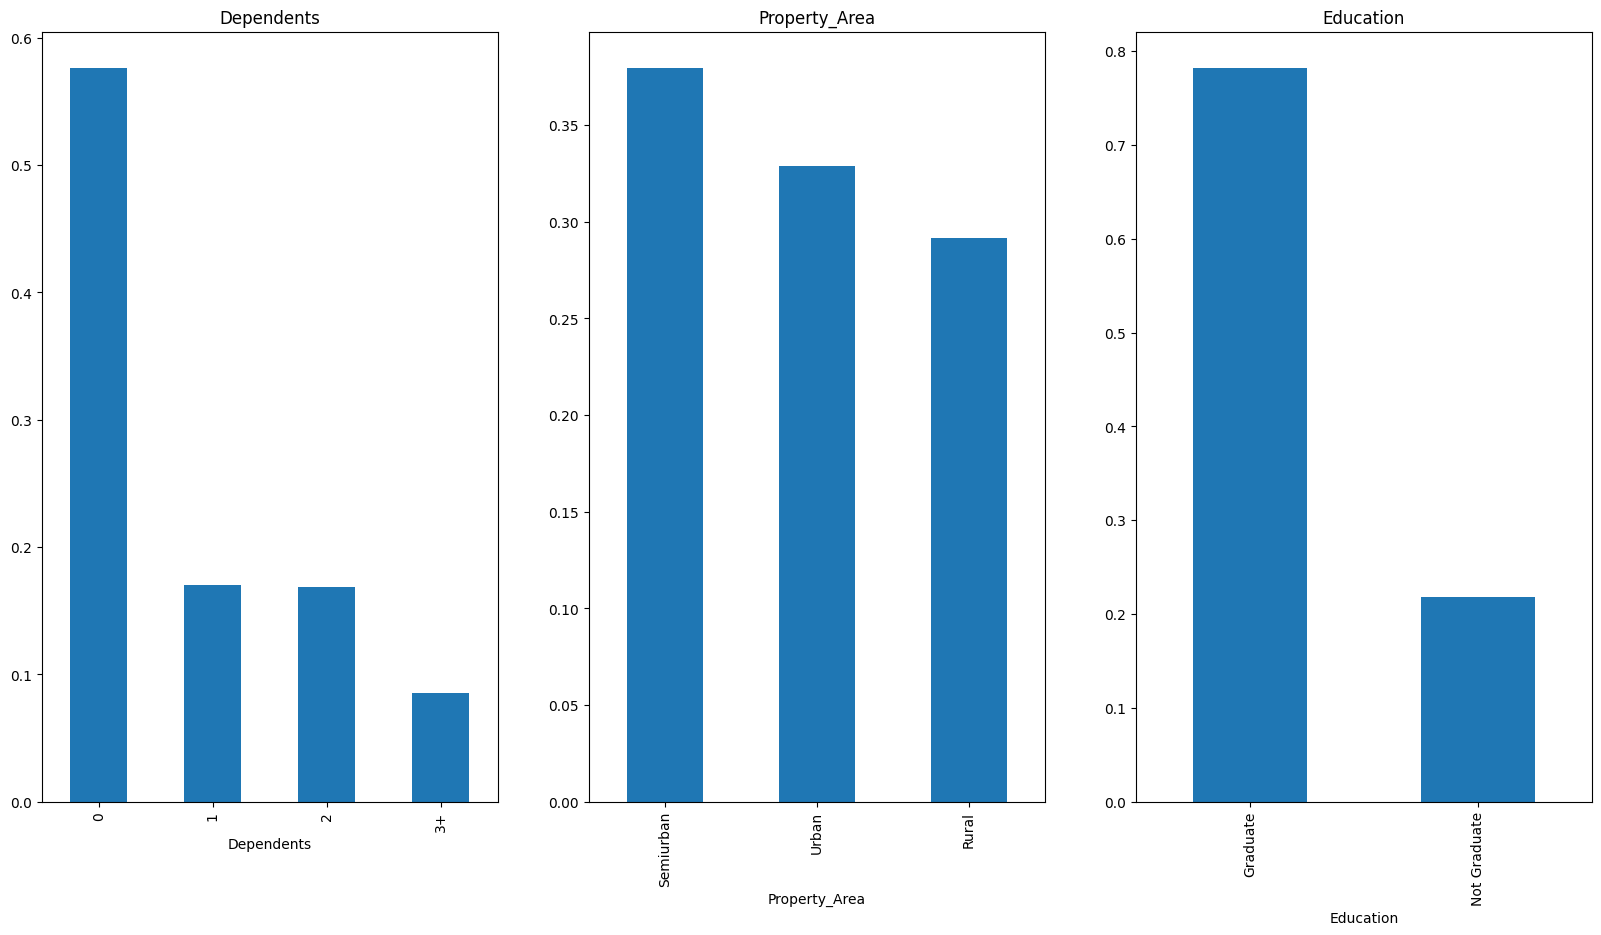

In [100]:
# ordinal variables
plt.figure(1)
plt.subplot(131)
train_data.Dependents.value_counts(normalize=True).plot.bar(figsize=(20,10), title='Dependents')
plt.subplot(132)
train_data.Property_Area.value_counts(normalize=True).plot.bar(figsize=(20,10), title='Property_Area')
plt.subplot(133)
train_data.Education.value_counts(normalize=True).plot.bar( title='Education')

plt.show()

Following inferences can be made from the above bar plots
- Most of the applicants don't have any dependants
- Around 80% of applicants are graduated
- Most of applicants are frrom semiurban areas

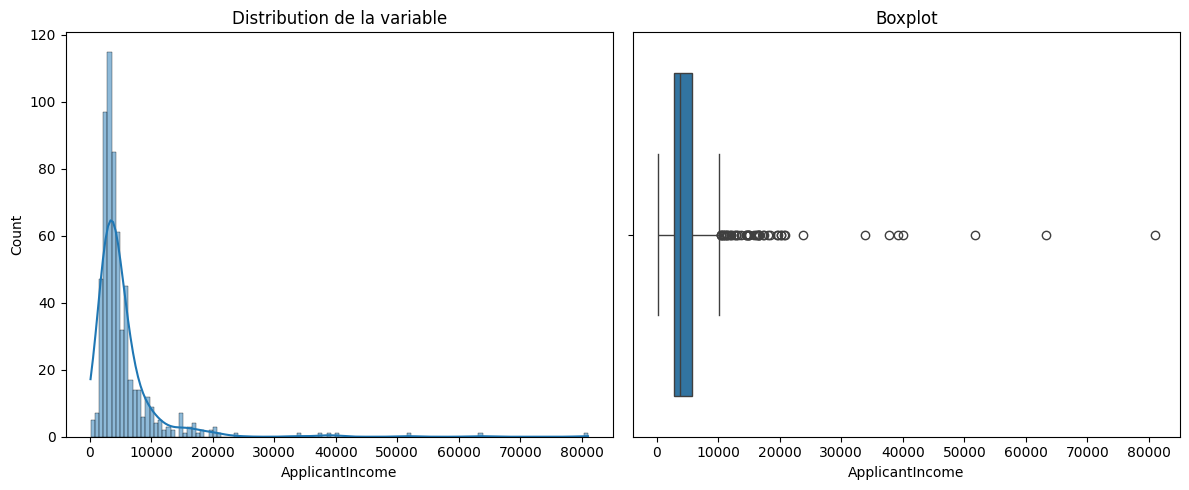

In [101]:
# Numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train_data.ApplicantIncome, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la variable')
sns.boxplot(x=train_data.ApplicantIncome, ax=axes[1])
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

- It can be inferred that most of data in the distribution of applicant income is towrds left which means that it is not normally distributed. We will try to make it normal since algorithms work better if data is normally distributed.
- The boxplot confirms the presence of outliers/extreme values.This can be attributed to the income disparity in the society. Part of this can be driven by the fact that we are looking at people with diffrent education levels. let us segrgate them by eductaion

<Axes: title={'center': 'ApplicantIncome'}, xlabel='Education'>

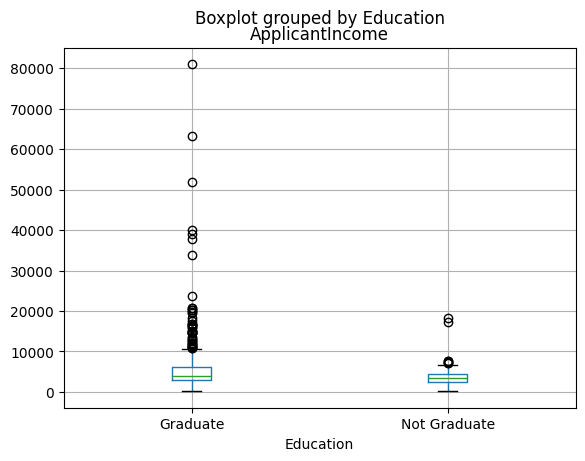

In [102]:
train_data.boxplot(column='ApplicantIncome', by='Education')

There are higher number of graduates with very high income which are appering to be the outliers

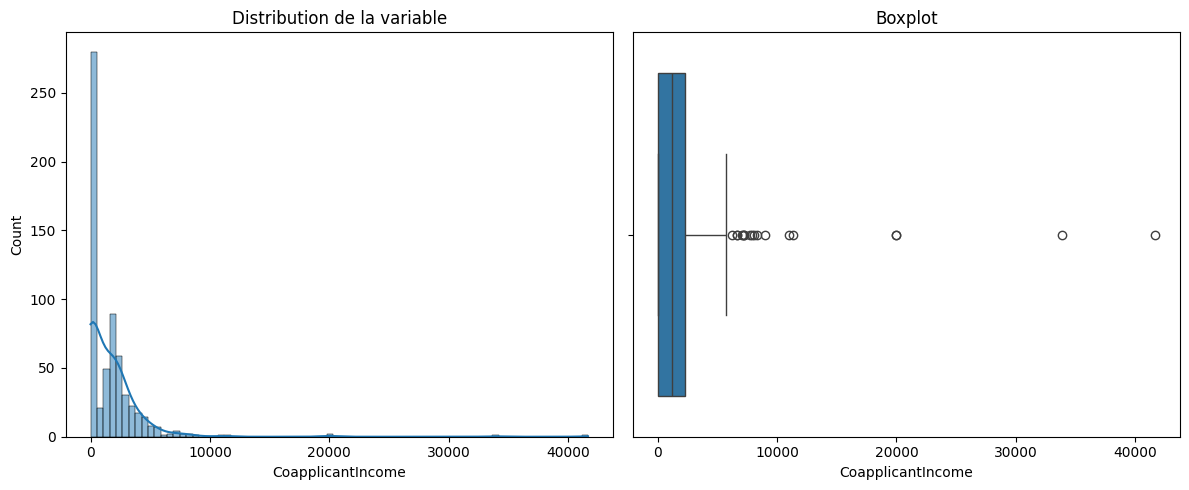

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train_data.CoapplicantIncome, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la variable')
sns.boxplot(x=train_data.CoapplicantIncome, ax=axes[1])
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

NOt normally distribued, a lot of ouliers and most of coapplicant's income are between 0 and 5000

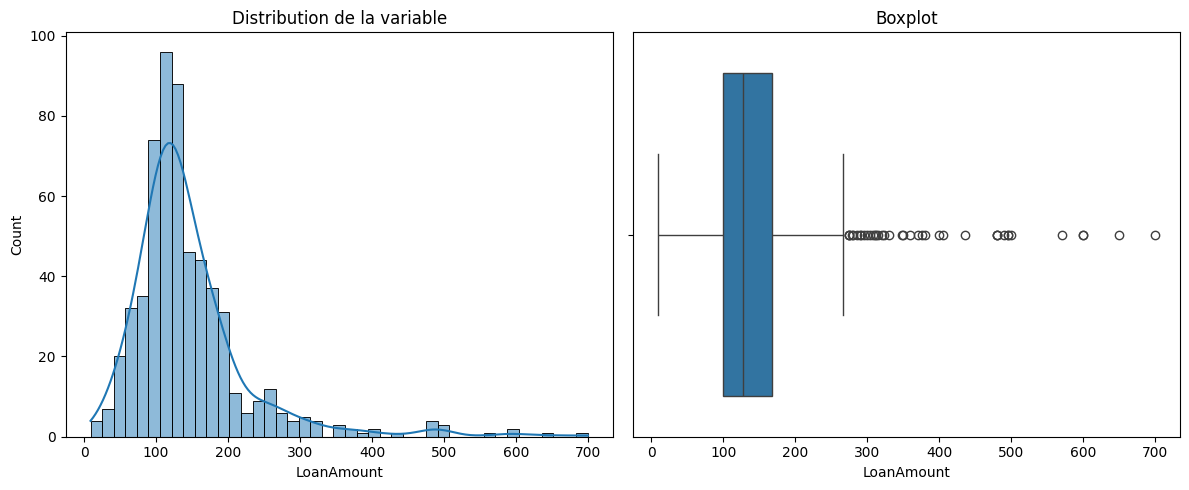

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train_data.LoanAmount, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la variable')
sns.boxplot(x=train_data.LoanAmount, ax=axes[1])
axes[1].set_title('Boxplot')
plt.tight_layout()
plt.show()

The distribution is fairly normal, a lot of outliers 

#### Bivariate Analysis

How well each feature is correlated with Loan_Status

##### 1. categorical variables vs target variable

<Axes: xlabel='Gender'>

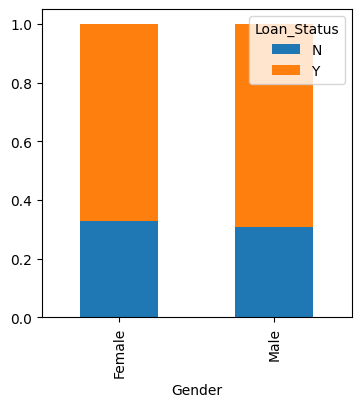

In [105]:
gender = pd.crosstab(train_data.Gender, train_data.Loan_Status)
gender.div(gender.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))

same proportion of approved loans for male and female people

<Axes: xlabel='Self_Employed'>

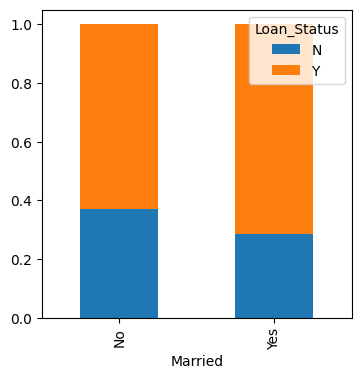

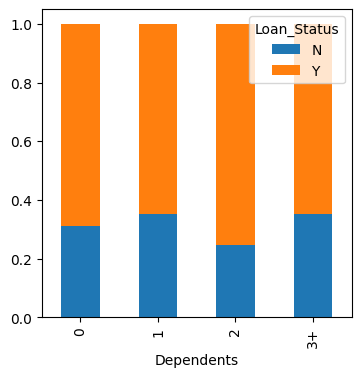

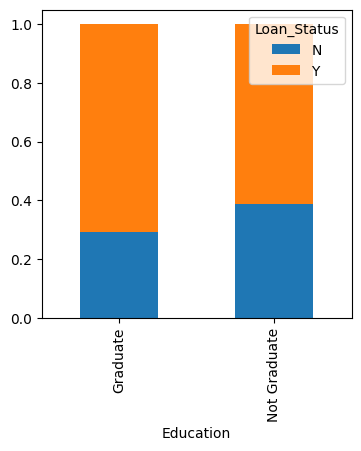

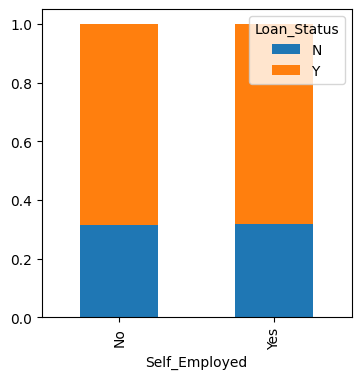

In [106]:
married = pd.crosstab(train_data.Married, train_data.Loan_Status)
dependents = pd.crosstab(train_data.Dependents, train_data.Loan_Status)
education = pd.crosstab(train_data.Education, train_data.Loan_Status)
Self_Employed = pd.crosstab(train_data.Self_Employed, train_data.Loan_Status)

married.div(married.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))
dependents.div(dependents.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))
education.div(education.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))

- Proportion of married applicants is higher for approved loans
- proportion of approved loans for graduated applicants is higher
- Distribution of applicants with 1 or +3 dependents are similar accross both categories of loan status
- Nothing significant to infer from self_employment vs Loan status

<Axes: xlabel='Property_Area'>

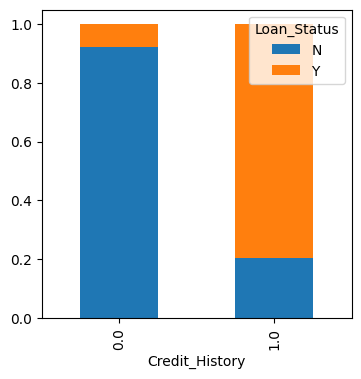

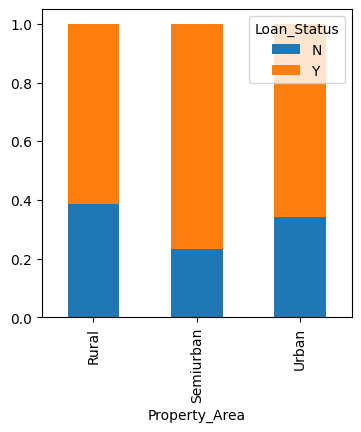

In [107]:
credit_hist = pd.crosstab(train_data.Credit_History, train_data.Loan_Status)
Property_Area = pd.crosstab(train_data.Property_Area, train_data.Loan_Status)

credit_hist.div(credit_hist.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))

- Applicants with credit history as 1 are more likely to get their loan approved
- proportion of approved loans is higher in semiurban area comapred to that in rural and urban areas

##### 2. numerical features vs target variable

<Axes: xlabel='Loan_Status'>

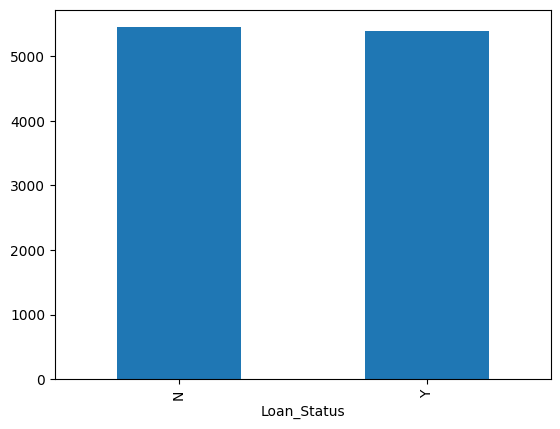

In [108]:
## let s see the mean income of perople for each loan status category
train_data.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

There is no change in the mean income, let's make bins for the applicant income

<Axes: xlabel='Income_Bin'>

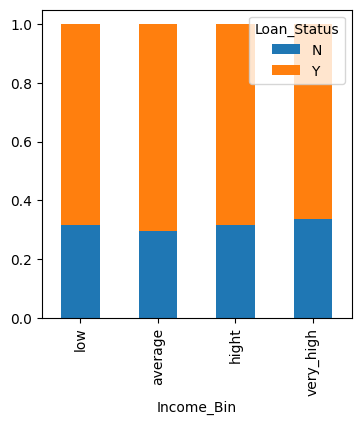

In [109]:
bins = [0, 2500, 4000, 6000, 81000]
groups = ['low', 'average', 'hight', 'very_high']
train_data['Income_Bin'] = pd.cut(train_data.ApplicantIncome, bins, labels=groups)
test_data['Income_Bin'] = pd.cut(test_data.ApplicantIncome, bins, labels=groups)

Income_Bin = pd.crosstab(train_data.Income_Bin, train_data.Loan_Status)

Income_Bin.div(Income_Bin.sum(1).astype(float), axis=0).plot(kind='bar', stacked=True, figsize=(4, 4))

It can be inferred that Applicant income doesn't affect the chance to loan approval

thera re also other variables to be added

### Correlation matrix

<Axes: >

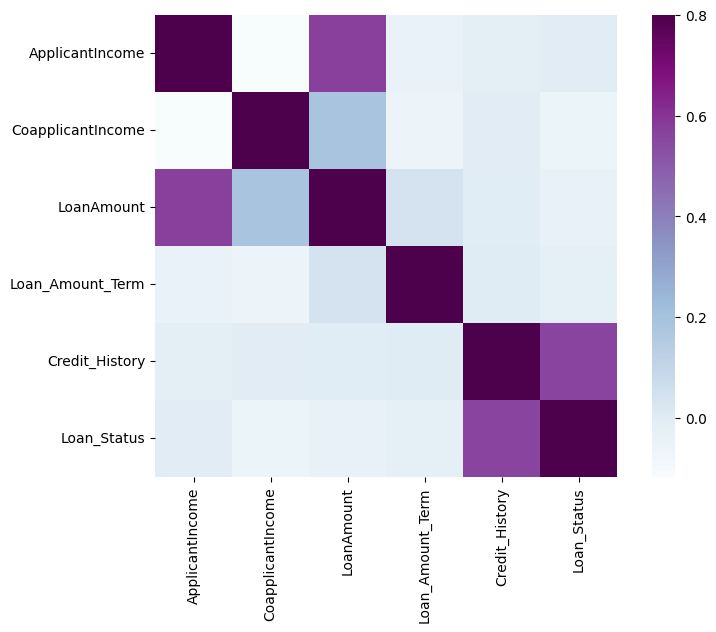

In [110]:
# lets see the correlation between numerical variables and target variable
train_data.drop(columns=['Income_Bin'])
train_data.Dependents.replace('3+', 3, inplace=True)
test_data.Dependents.replace('3+', 3, inplace=True)

train_data.Loan_Status.replace('Y', 1, inplace=True)
train_data.Loan_Status.replace('N', 0, inplace=True)
train_num = train_data.select_dtypes(include='number')
matrix = train_num.corr()
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(matrix, vmax=.8, square=True, cmap='BuPu')

Credit history and ApplicantIncome are the most correlated variables with loan status

### Preprocessing data

treat missing values and outliers because they can have adverse effect on the model performance
- impute missing values for categorical variables with mode
- impute missing values for numerical variables with mean or median
- Treat outliers because they affect the distribution of data, they have significant effect on the mean and standar deviation (median and mode are not affected) hence they affect the distribution

In [111]:
train_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
Income_Bin            0
dtype: int64

In [112]:
train_data['Gender'].fillna(train_data.Gender.mode()[0], inplace=True)
train_data['Married'].fillna(train_data.Married.mode()[0], inplace=True)
train_data['Dependents'].fillna(train_data.Dependents.mode()[0], inplace=True)
train_data['Self_Employed'].fillna(train_data.Self_Employed.mode()[0], inplace=True)
train_data['Credit_History'].fillna(train_data.Credit_History.mode()[0], inplace=True)

In [113]:
train_data.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

360 is the value repeating the most so we can replace nans with mode

as also for LoanAmount ther is a lot of outliers so mean will not be the proper approach as it is highly affected by the presence of ouliers

In [114]:
train_data['Loan_Amount_Term'].fillna(train_data.Loan_Amount_Term.mode()[0], inplace=True)
train_data['LoanAmount'].fillna(train_data.LoanAmount.median(), inplace=True)

In [115]:
train_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Income_Bin           0
dtype: int64

Let's fill missing values in test set also

In [116]:
test_data['Gender'].fillna(train_data.Gender.mode()[0], inplace=True)
test_data['Married'].fillna(train_data.Married.mode()[0], inplace=True)
test_data['Dependents'].fillna(train_data.Dependents.mode()[0], inplace=True)
test_data['Self_Employed'].fillna(train_data.Self_Employed.mode()[0], inplace=True)
test_data['Credit_History'].fillna(train_data.Credit_History.mode()[0], inplace=True)
test_data['Loan_Amount_Term'].fillna(train_data.Loan_Amount_Term.mode()[0], inplace=True)
test_data['LoanAmount'].fillna(train_data.LoanAmount.median(), inplace=True)

#### treat outliers
One way to remove skewness is by doing log transfromation. As we take the log transformation we don't affect the smaller values, but reduces the larger values so we get a normal distribution


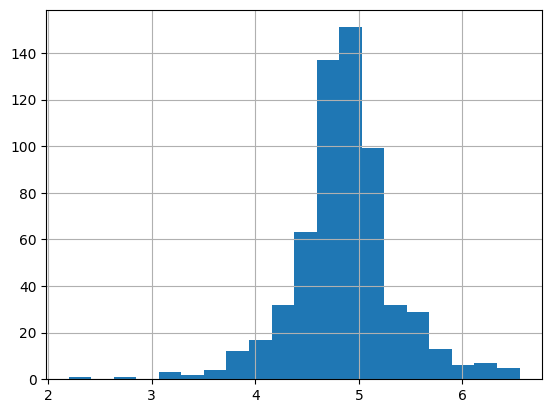

In [117]:
train_data['LoanAmount_log'] = np.log(train_data.LoanAmount)
train_data['LoanAmount_log'].hist(bins=20)
test_data['LoanAmount_log'] = np.log(test_data.LoanAmount)

Now the distribution looks much closer to normal distribution

### Model building and prediction

##### 1. first try

In [118]:
# Let's drop loan_id variable as it has no effect on target variable
train_data = train_data.drop('Loan_ID', axis=1)
test_data = test_data.drop('Loan_ID', axis=1) 

X = train_data.drop('Loan_Status', axis=1)
y = train_data.Loan_Status

In [119]:
# make dummy variables for categorical variables
X = pd.get_dummies(X)
train_data = pd.get_dummies(train_data)
test_data= pd.get_dummies(test_data)

# we will split train set into train and validate to validate model predictions
from sklearn.model_selection import train_test_split
X_train, x_cv, y_train, y_cv = train_test_split(X, y, test_size=0.3)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [120]:
y_cv_pred = model.predict(x_cv)
accuracy_score(y_cv, y_cv_pred)

0.7945945945945946

In [121]:
test_data.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'LoanAmount_log', 'Gender_Female',
       'Gender_Male', 'Married_No', 'Married_Yes', 'Dependents_3',
       'Dependents_0', 'Dependents_1', 'Dependents_2', 'Education_Graduate',
       'Education_Not Graduate', 'Self_Employed_No', 'Self_Employed_Yes',
       'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban',
       'Income_Bin_low', 'Income_Bin_average', 'Income_Bin_hight',
       'Income_Bin_very_high'],
      dtype='object')

In [123]:
# do predictions for test set
pred_test = model.predict(test_data)
submission = pd.read_csv('data/sample_submission_49d68Cx.csv')
submission['Loan_Status'] = pred_test  # to be transformed to Y and N
submission['Loan_ID'] = test_original['Loan_ID']

submission['Loan_Status'].replace(1, 'Y', inplace=True)
submission['Loan_Status'].replace(0, 'N', inplace=True)
submission.to_csv('results/logistic.csv')